In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. LOAD DATA ──────────────────────────────────────────
df = pd.read_csv(r'C:\Users\VICTUS\Downloads\Crimes_-_2001_to_Present_20260307.csv')  # ← change this

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

Shape: (170776, 22)
Columns: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']
         ID Case Number                    Date                    Block  \
0  14075483    JK105557  12/31/2025 11:58:00 PM       050XX S PAULINA ST   
1  14070833    JK100050  12/31/2025 11:55:00 PM  053XX W WASHINGTON BLVD   
2  14070845    JK100006  12/31/2025 11:54:00 PM          013XX W LAKE ST   

   IUCR         Primary Type  \
0  0560              ASSAULT   
1  0930  MOTOR VEHICLE THEFT   
2  0454              BATTERY   

                                         Description Location Description  \
0                                             SIMPLE            RESIDENCE   
1                      THEFT / RECOVERY - AUTOMOBILE            APARTMENT   
2  AGGRAVATED P.O. - HANDS, FISTS

In [9]:
# ── 2. KEEP ONLY NEEDED COLUMNS ───────────────────────────
df = df[['Date', 'Primary Type', 'Latitude', 'Longitude']].copy()

# ── 3. DROP NULLS ──────────────────────────────────────────
print(f"Before dropping nulls: {len(df)} rows")
df.dropna(subset=['Latitude', 'Longitude'], inplace=True)
print(f"After dropping nulls: {len(df)} rows")

# ── 4. EXTRACT HOUR FROM DATE ──────────────────────────────
# Date format in Chicago data: "12/31/2020 11:59:00 PM"
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')
df['hour'] = df['Date'].dt.hour
print("Hour extraction sample:")
print(df[['Date', 'hour']].head(5))

# ── 5. FILTER TO CHICAGO BOUNDING BOX ─────────────────────
# Chicago rough bounds
df = df[
    (df['Latitude']  > 41.6) & (df['Latitude']  < 42.1) &
    (df['Longitude'] > -87.95) & (df['Longitude'] < -87.5)
]
print(f"After bounding box filter: {len(df)} rows")

# ── 6. ASSIGN SEVERITY SCORES ─────────────────────────────
severity_map = {
    'HOMICIDE':                 10,
    'CRIMINAL SEXUAL ASSAULT':  10,
    'KIDNAPPING':               9,
    'WEAPONS VIOLATION':        8,
    'ASSAULT':                  7,
    'BATTERY':                  6,
    'STALKING':                 5,
    'ROBBERY':                  8,
    'MOTOR VEHICLE THEFT':      3,
    'CRIMINAL DAMAGE':          2,
    'THEFT':                    2,
}

df['severity'] = df['Primary Type'].map(severity_map)

# Check what crime types didn't get mapped
unmapped = df[df['severity'].isna()]['Primary Type'].unique()
print(f"\nUnmapped crime types (will get severity 1): {unmapped}")

df['severity'] = df['severity'].fillna(1).astype(int)

# ── 7. SUMMARY ─────────────────────────────────────────────
print("\n── CRIME TYPE DISTRIBUTION ──")
print(df['Primary Type'].value_counts())

print("\n── SEVERITY DISTRIBUTION ──")
print(df['severity'].value_counts().sort_index())

print("\n── HOUR DISTRIBUTION ──")
print(df.groupby('hour').size())

# ── 8. SAVE CLEAN DATA ────────────────────────────────────
df.to_csv('chicago_crimes_clean.csv', index=False)
print("\n✅ Saved to chicago_crimes_clean.csv")
print(f"Final shape: {df.shape}")

Before dropping nulls: 170750 rows
After dropping nulls: 170750 rows
Hour extraction sample:
                 Date  hour
0 2025-12-31 23:58:00    23
1 2025-12-31 23:55:00    23
2 2025-12-31 23:54:00    23
3 2025-12-31 23:50:00    23
4 2025-12-31 23:50:00    23
After bounding box filter: 170750 rows

Unmapped crime types (will get severity 1): []

── CRIME TYPE DISTRIBUTION ──
Primary Type
THEFT                      55025
BATTERY                    42534
CRIMINAL DAMAGE            26202
ASSAULT                    21559
MOTOR VEHICLE THEFT        17229
WEAPONS VIOLATION           5444
CRIMINAL SEXUAL ASSAULT     1672
STALKING                     570
HOMICIDE                     426
KIDNAPPING                    89
Name: count, dtype: int64

── SEVERITY DISTRIBUTION ──
severity
2     81227
3     17229
5       570
6     42534
7     21559
8      5444
9        89
10     2098
Name: count, dtype: int64

── HOUR DISTRIBUTION ──
hour
0     10415
1      5906
2      5137
3      4666
4      3652
5 

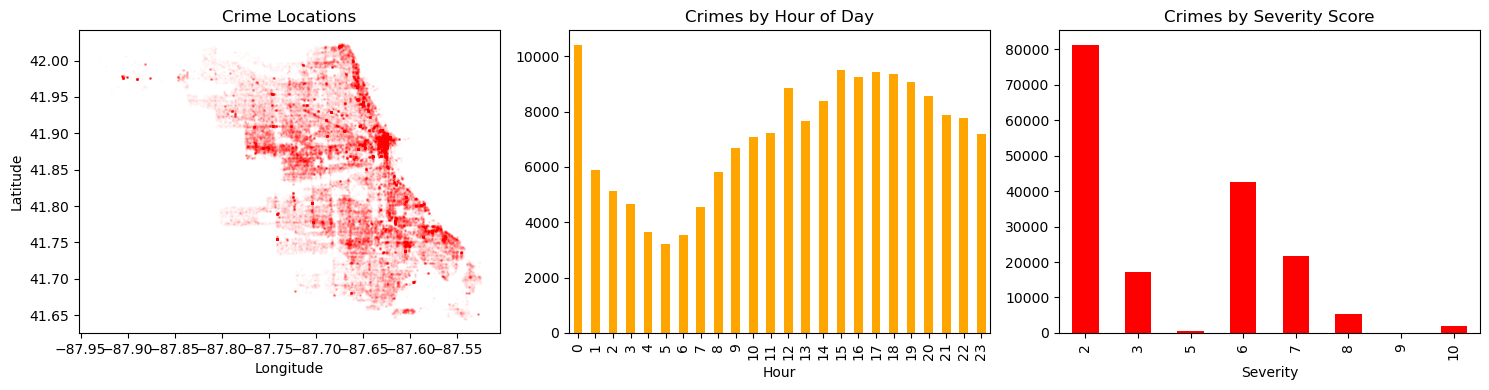

✅ Plot saved


In [8]:
# ── 9. QUICK VISUALISATION ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Crime dots on map
axes[0].scatter(df['Longitude'], df['Latitude'], 
                alpha=0.01, s=0.5, c='red')
axes[0].set_title('Crime Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot 2: Crimes by hour
df.groupby('hour').size().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Crimes by Hour of Day')
axes[1].set_xlabel('Hour')

# Plot 3: Crimes by severity
df.groupby('severity').size().plot(kind='bar', ax=axes[2], color='red')
axes[2].set_title('Crimes by Severity Score')
axes[2].set_xlabel('Severity')

plt.tight_layout()
plt.savefig('step1_verification.png', dpi=150)
plt.show()
print("✅ Plot saved")

In [10]:
!pip install hdbscan

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/671.8 kB ? eta -:--:--

In [26]:
# ── SMART SUBSAMPLE BEFORE HDBSCAN ───────────────────────
# Haversine needs a distance matrix — too expensive for 688k rows
# Solution: sample 80k rows, keeping severity distribution intact
# (stratified sample so violent crimes aren't lost)

import pandas as pd
import numpy as np
import hdbscan
import json

print(f"Original weighted_df size: {len(weighted_df)}")

# Stratified sample — keep proportional severity representation
SAMPLE_SIZE = 80000

sampled_df = weighted_df.groupby('severity', group_keys=False).apply(
    lambda x: x.sample(
        min(len(x), int(SAMPLE_SIZE * len(x) / len(weighted_df))),
        random_state=42
    )
).reset_index(drop=True)

# If sample is still smaller than target, top it up randomly
if len(sampled_df) < SAMPLE_SIZE:
    remaining = weighted_df.drop(sampled_df.index, errors='ignore')
    extra = remaining.sample(
        min(SAMPLE_SIZE - len(sampled_df), len(remaining)),
        random_state=42
    )
    sampled_df = pd.concat([sampled_df, extra]).reset_index(drop=True)

print(f"Sampled size: {len(sampled_df)}")
print(f"Severity distribution preserved:")
print(sampled_df['severity'].value_counts().sort_index())

Original weighted_df size: 688441
Sampled size: 80000
Severity distribution preserved:
severity
2     18878
3      6006
5       331
6     29659
7     17536
8      5060
9        93
10     2437
Name: count, dtype: int64


In [27]:
# ── CONVERT TO RADIANS ────────────────────────────────────
coords_rad = np.radians(sampled_df[['lat', 'lon']].values)
print(f"Feature matrix shape: {coords_rad.shape}")
print("Running HDBSCAN with haversine metric...")

Feature matrix shape: (80000, 2)
Running HDBSCAN with haversine metric...


In [28]:
# ── RUN HDBSCAN ON SAMPLE ─────────────────────────────────
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300,       # lower since we sampled down
    min_samples=20,
    metric='haversine',
    cluster_selection_method='leaf',
    core_dist_n_jobs=-1         # use all CPU cores
)
clusterer.fit(coords_rad)

labels = clusterer.labels_
probs  = clusterer.probabilities_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f"\n✅ Clusters found:   {n_clusters}")
print(f"   Noise points:     {n_noise} ({100*n_noise/len(labels):.1f}%)")
print(f"   Clustered points: {(labels != -1).sum()}")


✅ Clusters found:   65
   Noise points:     40184 (50.2%)
   Clustered points: 39816


In [29]:
# ── EXTRACT CLUSTER INFO ──────────────────────────────────
# Run this after picking best min_cluster_size from sweep above
# Replace 300 below with whichever gives 50-150 clusters

BEST_MCS = 300   # ← update this after seeing sweep results

final_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=BEST_MCS,
    min_samples=20,
    metric='haversine',
    cluster_selection_method='leaf',
    core_dist_n_jobs=-1
).fit(coords_rad)

labels = final_clusterer.labels_
probs  = final_clusterer.probabilities_

sampled_df['cluster']     = labels
sampled_df['probability'] = probs

cluster_info = {}
for label in sorted(set(labels)):
    if label == -1:
        continue
    mask           = sampled_df['cluster'] == label
    cluster_points = sampled_df[mask]
    cluster_info[int(label)] = {
        'centre_lat':   float(cluster_points['lat'].mean()),
        'centre_lon':   float(cluster_points['lon'].mean()),
        'intensity':    float(cluster_points['probability'].mean()),
        'size':         int(mask.sum()),
        'peak_hour':    int(cluster_points['hour'].mode()[0]),
        'avg_severity': float(cluster_points['severity'].mean())
    }

sorted_clusters = sorted(cluster_info.items(),
                          key=lambda x: x[1]['size'], reverse=True)

print(f"\n── TOP 10 DANGER CLUSTERS ──")
print(f"{'ID':>4} {'Lat':>10} {'Lon':>11} {'Size':>7} "
      f"{'Intensity':>10} {'PeakHr':>7} {'AvgSev':>8}")
print("-" * 65)
for label, info in sorted_clusters[:10]:
    print(f"{label:>4} {info['centre_lat']:>10.5f} "
          f"{info['centre_lon']:>11.5f} "
          f"{info['size']:>7} {info['intensity']:>10.3f} "
          f"{info['peak_hour']:>7} {info['avg_severity']:>8.2f}")

with open('chicago_clusters.json', 'w') as f:
    json.dump(cluster_info, f, indent=2)

print(f"\n✅ Saved {len(cluster_info)} clusters → chicago_clusters.json")


── TOP 10 DANGER CLUSTERS ──
  ID        Lat         Lon    Size  Intensity  PeakHr   AvgSev
-----------------------------------------------------------------
  55   41.86393   -87.71574    1633      0.884      20     5.99
  49   41.88186   -87.62739    1351      0.813      17     4.71
  36   41.74578   -87.60471    1255      0.871       0     5.65
  24   41.69632   -87.62043    1194      0.929       0     5.73
  46   41.76559   -87.57801    1188      0.887      16     5.61
   4   41.96376   -87.71662    1172      0.835      16     5.19
  43   41.75606   -87.56061    1141      0.905      17     5.60
  23   41.86242   -87.65949     934      0.892      20     5.30
  48   41.90225   -87.72512     915      0.925      19     5.67
  20   41.92754   -87.76765     912      0.959      19     5.34

✅ Saved 65 clusters → chicago_clusters.json
